In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from nn_helpers import *
from spectra import MoogStokesModel

## Create parameters to sample

Before we do anything else, we need to deal with the fact that Teff ~ 10^4 while
other parameters are closer to 1. Use the ParamScaler class to normalize the parameters.

In [2]:
# For example,
scaler = ParamScaler()
p_physical = {"Teff": 4000, "logg": 4.25, "vsini": 37, "B": 1.0}
p_nn = scaler.physical_to_nn(p_physical)
print("Physical parameters:", p_physical)
print("NN parameters:", p_nn)

# We can go backwards like this:
p_physical_recovered = scaler.nn_to_physical(p_nn)
print("Recovered physical parameters:", p_physical_recovered)

Physical parameters: {'Teff': 4000, 'logg': 4.25, 'vsini': 37, 'B': 1.0}
NN parameters: {'Teff': np.float64(-2.0), 'logg': np.float64(0.5), 'vsini': np.float64(1.25), 'B': np.float64(-1.0)}
Recovered physical parameters: {'Teff': np.float64(4000.0), 'logg': np.float64(4.25), 'vsini': np.float64(37.0), 'B': np.float64(1.0)}


Now, we will generate the model parameters that should be used to create the radiative transfer models.
These parameters are saved to a TXT file so that they can be imported later.

In [9]:
fname_params = "model_params_to_generate.txt"
m_sobol = 12
N_params = 4      # ignore veiling
seed = 287

# Define the lower and upper bounds for the generated parameters
p_lower = {
    "Teff": 3000,
    "vsini": 2,
    "logg": 2.5,
    "B": 1.0
}

p_upper = {
    "Teff": 7000,
    "vsini": 42,
    "logg": 5.25,
    "B": 3.0
}
print("Number of models: ", 2**m_sobol)

param_samples_phys, param_samples_nn = make_sobol_samples(N_params, m_sobol, p_lower, p_upper, fname_params, seed)

Number of models:  4096


Verify the distribution of parameters by plotting them.

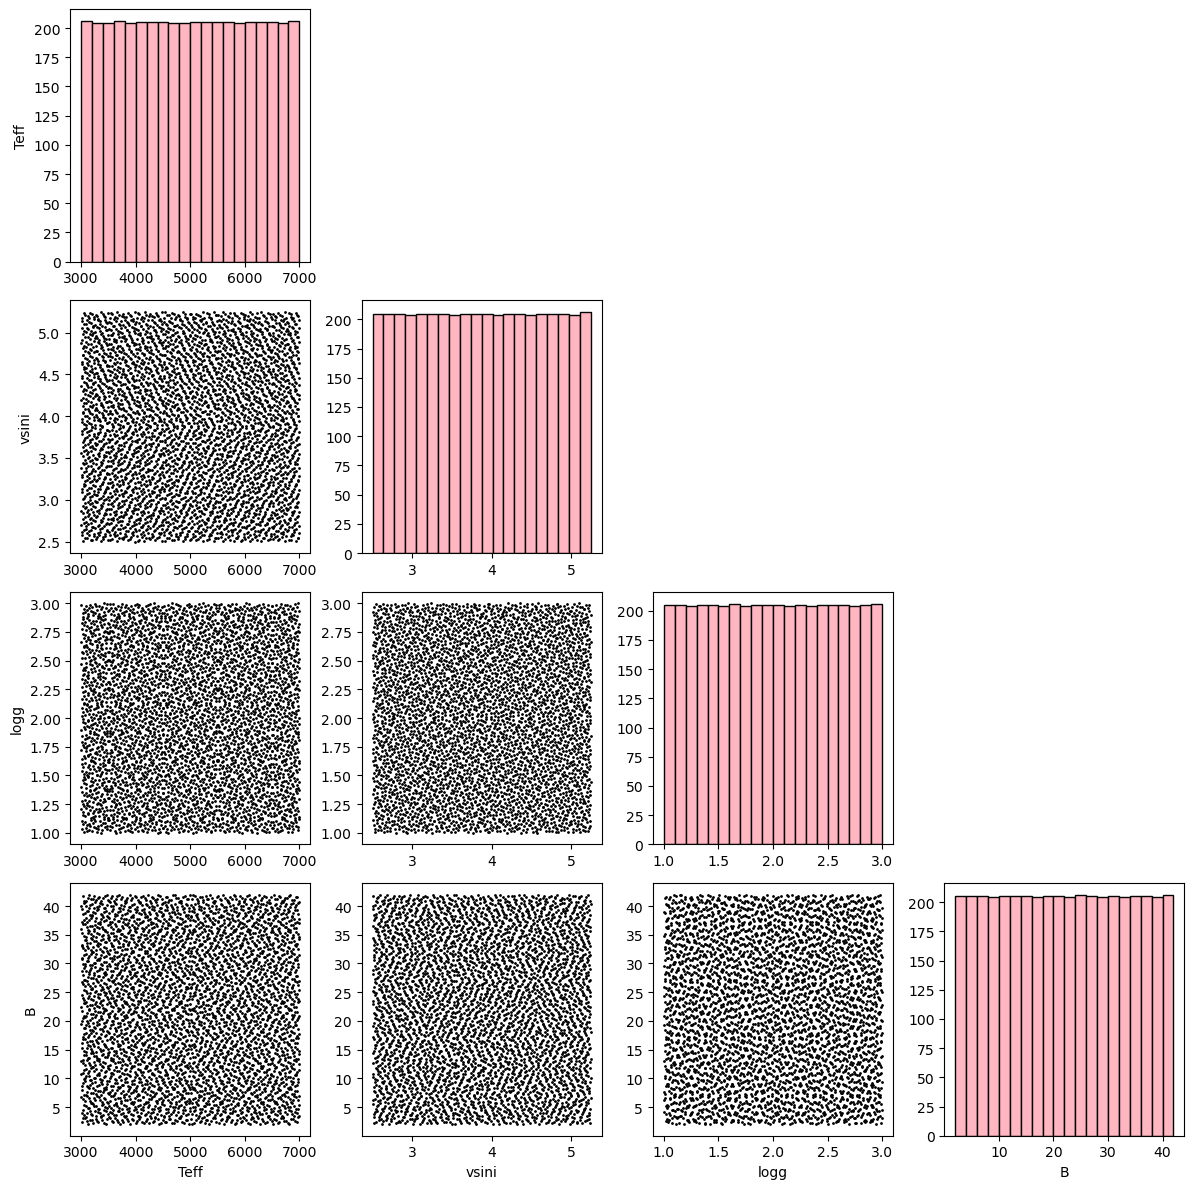

In [10]:
fig, axs = plt.subplots(N_params, N_params, figsize=(12, 12))

param_names = list(p_lower.keys())

for i in range(N_params):
    for j in range(N_params):
        if i == j:
            axs[i, j].hist(param_samples_phys[:, i], bins=20, color='lightpink', edgecolor='black')
        elif i < j:
            axs[i, j].axis("off")
            continue

        else:
            axs[i, j].scatter(param_samples_phys[:, j], param_samples_phys[:, i], s=1, c='k')
        # Labels
        if j == 0:
            axs[i, j].set_ylabel(param_names[i])
        if i == N_params - 1:
            axs[i, j].set_xlabel(param_names[j])

plt.tight_layout()
plt.show()


## Generate training data
For the test, I will use linear interpolation. This should be replaced by the actual MoogStokes radiative transfer models.

In [2]:
from interpolate_moogstokes import check_moogstokes_grid_rectangularity, interpolate_moogstokes_to_points

interpolation_bounds = {
    "Teff":  (3000, 7000),
    "logg":  (2.5, 5.25),
    "B":     (0, 3.0),
    "vsini": (2, 42),
}

check_moogstokes_grid_rectangularity(
    "data/moog-stokes/",
    interpolation_bounds,
)

Grid is rectangular and complete.
  Teff:  [3000, 3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000, 5200, 5400, 5600, 5800, 6000, 6200, 6400, 6600, 6800, 7000]
  logg:  [2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25]
  B:     [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
  vsini: [2.0, 7.0, 12.0, 17.0, 22.0, 27.0, 32.0, 37.0, 42.0]


True

In [3]:
fname_params = "model_params_to_generate.txt"
params_samples_phys = np.loadtxt(fname_params, skiprows=1)

region_sizes = np.zeros(7, dtype=int)

for r in range(7):
    interpolate_moogstokes_to_points(
        models_dir = "data/moog-stokes/",
        output_dir = "data/moog-stokes-itp/",
        region = r,
        target_params = params_samples_phys,
        interpolation_bounds = interpolation_bounds,
        verbose = True
    )

    # Also check how many wavelength points are in each region. We need this
    # to create the neural network output layer

    testmodel = MoogStokesModel(
        Teff = params_samples_phys[0, 0],
        logg=params_samples_phys[0, 1],
        rK = 0,
        B = params_samples_phys[0, 2],
        vsini = params_samples_phys[0, 3],
        region = r
        )
    
    region_sizes[r] = len(testmodel.x)


------------------------------------------------------------------------
Interpolating MoogStokes models (region=0)
------------------------------------------------------------------------
[1] Loading original models
    Applying interpolation bounds and reading spectra...


KeyboardInterrupt: 

In [13]:
print(region_sizes)
with open("data/region_sizes.txt", "w") as f:
    f.write("# region size\n")
    for r in range(7):
        f.write(f"{r} {region_sizes[r]}\n")

[1099  548  518  688 1399  849 1231]


Set up a file that will contain the 4 input parameters and the file name.
This will be used as an input the pytorch dataset class. Divide the models into
a training, validation, and testing dataset.

In [14]:
p_train = 0.8  # fraction of data to use for training
p_val = 0.1    # validation, which refers to tuning the hyperparameters
p_test = 1 - p_train - p_val  # final testing

fname_train = "data/train_params.txt"
fname_val = "data/val_params.txt"
fname_test = "data/test_params.txt"

# Divide up the data by shuffling indices
N_models = len(params_samples_phys)
N_train = round(N_models * p_train)
N_val = round(N_models * p_val)
N_test = N_models - N_train - N_val

seed = 287
indices = np.arange(N_models)
np.random.seed(seed)
np.random.shuffle(indices)

train_indices = indices[:N_train]
val_indices = indices[N_train:N_train + N_val]
test_indices = indices[N_train + N_val:]

save_params_to_txt(params_samples_phys[train_indices], fname_train)
save_params_to_txt(params_samples_phys[val_indices], fname_val)
save_params_to_txt(params_samples_phys[test_indices], fname_test)

## Train a neural network

In [33]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(DEVICE)

cpu


In [34]:
fname_train = "data/train_params.txt"
fname_val = "data/val_params.txt"
fname_test = "data/test_params.txt"
batch_size = 64
region = 0

dataloader_train = DataLoader(
    MoogStokesTorchDataset(fname_train, region=region),
    batch_size = batch_size,
    shuffle = True
)
dataloader_val = DataLoader(
    MoogStokesTorchDataset(fname_val, region=region),
    batch_size = batch_size,
    shuffle = False
)

Text(0.5, 1.0, 'Teff: 3506 K, logg: 3.314, B: 1.639 kG, vsini: 11.662 km/s')

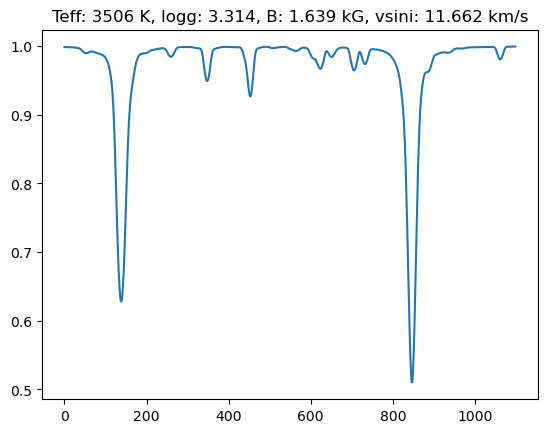

In [35]:
# Show one model from the dataloader to check that it's working
train_params, train_flux = next(iter(dataloader_train))
scaler = ParamScaler()
p_phys = scaler.nn_to_physical(train_params[0].numpy())
plt.figure() 
plt.plot(train_flux[0].numpy())
plt.title(f"Teff: { p_phys[0]:.0f} K, logg: {p_phys[1]:.3f}, B: {p_phys[2]:.3f} kG, vsini: {p_phys[3]:.3f} km/s")

In [36]:
for X, y in dataloader_train:
    print(X.shape, y.shape)
    break

torch.Size([64, 4]) torch.Size([64, 1099])


In [60]:
class SpectralInterpolatorNeuralNetwork(nn.Module):
    def __init__(self, num_params, num_wavelengths):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(num_params, 128),
            #nn.LeakyReLU(0.01),
            #nn.ReLU(),
            nn.Tanh(),
            nn.Linear(128, 256),
            #nn.LeakyReLU(0.01),
            #nn.ReLU(),
            nn.Tanh(),
            nn.Linear(256, num_wavelengths),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [61]:
# NOTE: You will have to reinitialize the model if you want to train from scratch
# again.
Nx = dataloader_train.dataset.num_wavelengths
model = SpectralInterpolatorNeuralNetwork(num_params=4, num_wavelengths=Nx)
print(model)

SpectralInterpolatorNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=1099, bias=True)
  )
)


In [63]:
epochs = 400
loss_fn = nn.MSELoss()
#optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

train_losses = []
val_losses = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    # Training
    size = len(dataloader_train.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader_train):
        X, y = X.to(DEVICE), y.to(DEVICE)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
            train_losses.append(loss)
        
    # Validation
    size = len(dataloader_val.dataset)
    num_batches = len(dataloader_val)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader_val:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    val_losses.append(test_loss)
    print(f"Test Error: Avg loss: {test_loss:>8f}")

print("Done!")

Epoch 1
-------------------------------
loss: 0.811343  [   64/ 3277]
loss: 0.777450  [  704/ 3277]
loss: 0.722512  [ 1344/ 3277]
loss: 0.661501  [ 1984/ 3277]
loss: 0.653926  [ 2624/ 3277]
loss: 0.564995  [ 3264/ 3277]
Test Error: Avg loss: 0.570491
Epoch 2
-------------------------------
loss: 0.594419  [   64/ 3277]
loss: 0.492447  [  704/ 3277]
loss: 0.478975  [ 1344/ 3277]
loss: 0.402692  [ 1984/ 3277]
loss: 0.333115  [ 2624/ 3277]
loss: 0.318596  [ 3264/ 3277]
Test Error: Avg loss: 0.299828
Epoch 3
-------------------------------
loss: 0.296154  [   64/ 3277]
loss: 0.235290  [  704/ 3277]
loss: 0.231620  [ 1344/ 3277]
loss: 0.180988  [ 1984/ 3277]
loss: 0.157303  [ 2624/ 3277]
loss: 0.099162  [ 3264/ 3277]
Test Error: Avg loss: 0.120606
Epoch 4
-------------------------------
loss: 0.100534  [   64/ 3277]
loss: 0.082529  [  704/ 3277]
loss: 0.102284  [ 1344/ 3277]
loss: 0.061424  [ 1984/ 3277]
loss: 0.072487  [ 2624/ 3277]
loss: 0.047745  [ 3264/ 3277]
Test Error: Avg loss: 0.049

In [64]:
torch.save(model.state_dict(), "data/nn_region_0.pt")

/var/folders/pv/dz5xq3sj059bg3y61lpq5r4r0000gn/T/ipykernel_11260/3658096976.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


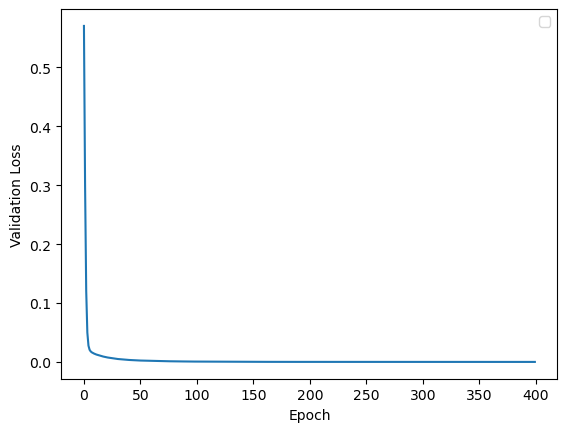

In [65]:
plt.figure()
plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

## Verify the performance of the NN

In [66]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(DEVICE)

cpu


In [67]:
model = SpectralInterpolatorNeuralNetwork(num_params=4, num_wavelengths=Nx)
model.load_state_dict(torch.load("data/nn_region_0.pt", weights_only=True))
model.eval()

SpectralInterpolatorNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=1099, bias=True)
  )
)

In [68]:
fname_test = "data/test_params.txt"
region = 0
data_test = MoogStokesTorchDataset(fname_test, region=region)

In [69]:
testidx = 5
x, y_actual = data_test[testidx][0], data_test[testidx][1]
y_actual = y_actual.numpy()
x = x.unsqueeze(0)  # add batch dimension

with torch.no_grad():
    x = x.to(DEVICE)
    pred = model(x)
    y_pred = pred.cpu().numpy()[0]

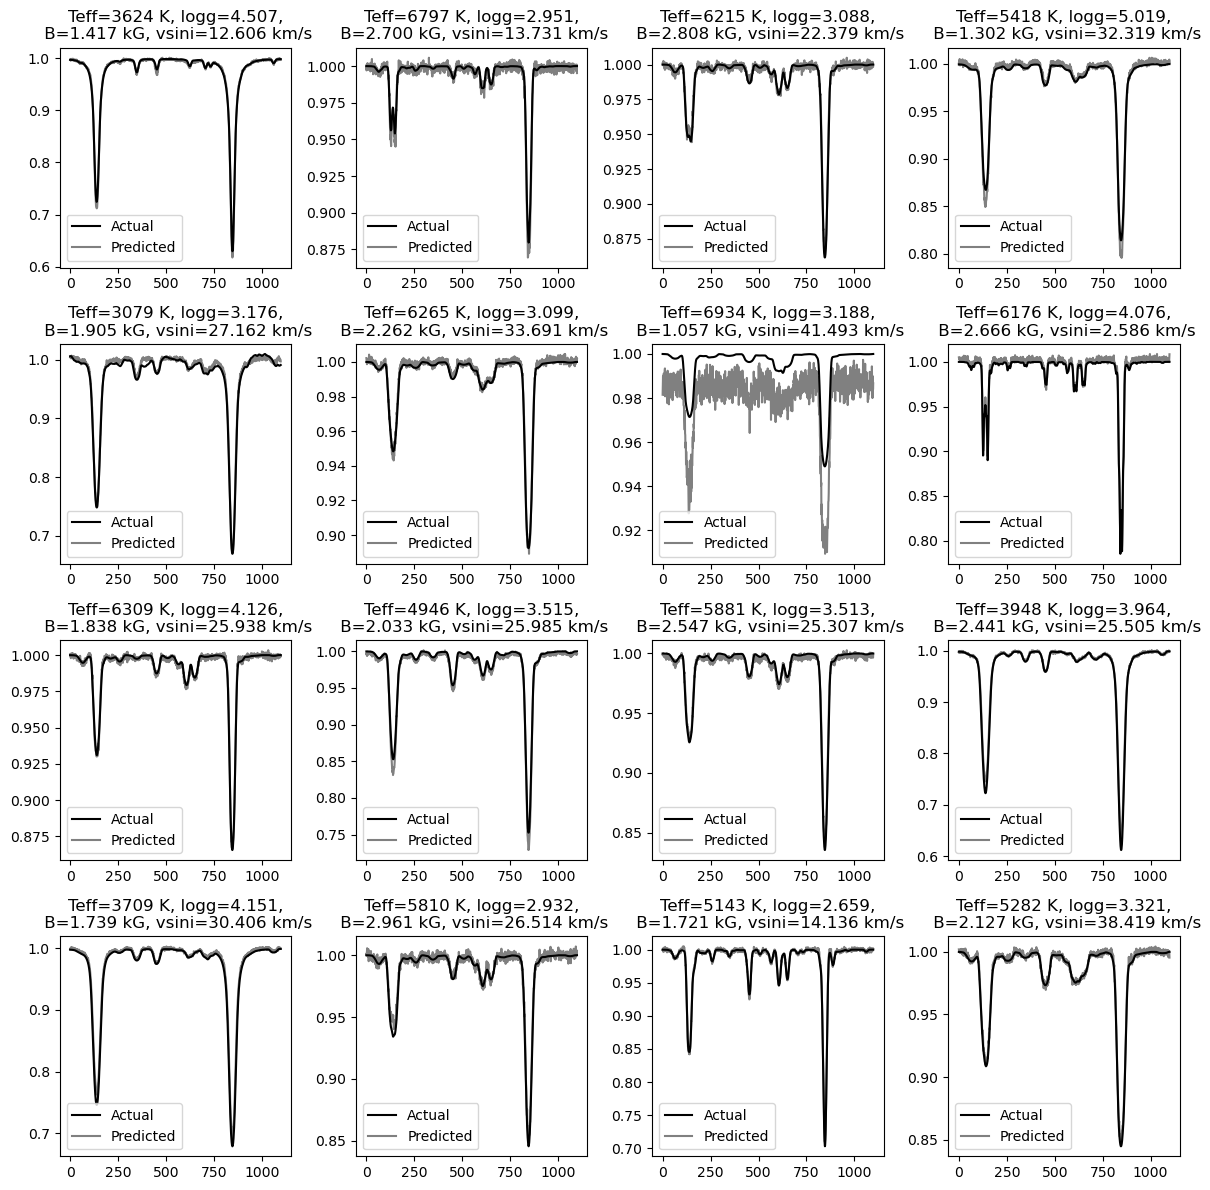

In [101]:
# Randomly plot a sample of 16 models from the test set
fig, axs = plt.subplots(4, 4, figsize=(12, 12))
for i in range(4):
    for j in range(4):
        idx = np.random.randint(len(data_test))
        x, y_actual = data_test[idx][0], data_test[idx][1]
        y_actual = y_actual.numpy()
        x = x.unsqueeze(0)  # add batch dimension

        with torch.no_grad():
            x = x.to(DEVICE)
            pred = model(x)
            y_pred = pred.cpu().numpy()[0]

        axs[i, j].plot(y_actual, label="Actual", color='k', zorder=1)
        axs[i, j].plot(y_pred, label="Predicted", color='gray', zorder=0)
        axs[i, j].legend()
        p_phys = scaler.nn_to_physical(data_test[idx][0].numpy())
        axs[i, j].set_title(f"Teff={p_phys[0]:.0f} K, logg={p_phys[1]:.3f},\n B={p_phys[2]:.3f} kG, vsini={p_phys[3]:.3f} km/s")
plt.tight_layout()
fig.savefig("figures/test_predictions.png", dpi=300, facecolor='white')
plt.show()

In [107]:
import time

tstart = time.time()
testidx = 5
x, y_actual = data_test[testidx][0], data_test[testidx][1]
y_actual = y_actual.numpy()
x = x.unsqueeze(0)  # add batch dimension

with torch.no_grad():
    x = x.to(DEVICE)
    pred = model(x)
    y_pred = pred.cpu().numpy()[0]

tend = time.time()
print(f"Inference time: {tend - tstart:.4f} seconds")

Inference time: 0.0033 seconds
